In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc,average_precision_score
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.tree import plot_tree

In [3]:
df=pd.read_csv(r"C:\Users\Dhruv\Downloads\cotton_Augmented_features.xls")
df

,image,red_intensity,green_intensity,blue_intensity,texture,edge_density,disease
0,augmented_Bacterial Blight0001.jpg,172.749939,214.713731,187.657945,29.300415,0.293725,Bacterial Blight
1,augmented_Bacterial Blight0002.jpg,172.749939,214.713731,187.657945,29.300415,0.293725,Bacterial Blight
2,augmented_Bacterial Blight0003.jpg,172.766431,214.744750,187.669720,29.192382,0.292520,Bacterial Blight
3,augmented_Bacterial Blight0004.jpg,178.657178,217.817108,193.727037,33.248349,0.273866,Bacterial Blight
4,augmented_Bacterial Blight0005.jpg,199.523792,220.028811,189.247580,35.060665,0.037164,Bacterial Blight
...,...,...,...,...,...,...,...
6995,augmented_Leaf Variegation0996.jpg,174.742322,197.408752,141.309628,32.220426,0.099620,Leaf Variegation
6996,augmented_Leaf Variegation0997.jpg,189.580278,207.636434,160.926677,40.481645,0.091966,Leaf Variegation
6997,augmented_Leaf Variegation0998.jpg,178.131728,200.325588,148.243048,33.268302,0.107803,Leaf Variegation
6998,augmented_Leaf Variegation0999.jpg,178.131728,200.325588,148.243048,33.268302,0.107803,Leaf Variegation


In [4]:
df.isnull().sum()

image              0
red_intensity      0
green_intensity    0
blue_intensity     0
texture            0
edge_density       0
disease            0
dtype: int64

In [5]:
df['disease']=df['disease'].map({'Bacterial Blight':0,'Curl Virus':1,'Healthy Leaf':2,'Herbicide Growth Damage':3,'Leaf Hopper Jassids':4,'Leaf Redding':5,'Leaf Variegation':6})

In [6]:
df.columns

Index(['image', 'red_intensity', 'green_intensity', 'blue_intensity',
       'texture', 'edge_density', 'disease'],
      dtype='str')

In [7]:
X=df[[ 'red_intensity', 'green_intensity', 'blue_intensity',
       'texture', 'edge_density']]
y=df['disease']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [9]:
# Model Selecion & tranning
for depth in [5, 10, 15, 20, 25, None]:

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    print(
        "Depth:", depth,
        "OOB Score:", round(model.oob_score_, 4)
    )

Depth: 5 OOB Score: 0.4755
Depth: 10 OOB Score: 0.6527
Depth: 15 OOB Score: 0.7151
Depth: 20 OOB Score: 0.7163
Depth: 25 OOB Score: 0.7188
Depth: None OOB Score: 0.7171


In [65]:
# Model Tranning
y_pred=model.predict(X_test)
proba=model.predict_proba(X_test)

In [11]:
# Accuracy
accuracy=accuracy_score(y_test,y_pred)
print("Random Forest Accuracy:",accuracy*100)

Random Forest Accuracy: 72.52380952380952


In [12]:
# feature Importances
feature_importances_=model.feature_importances_
print("Feature importances:",feature_importances_)

Feature importances: [0.19990244 0.20591855 0.19182034 0.21521261 0.18714606]


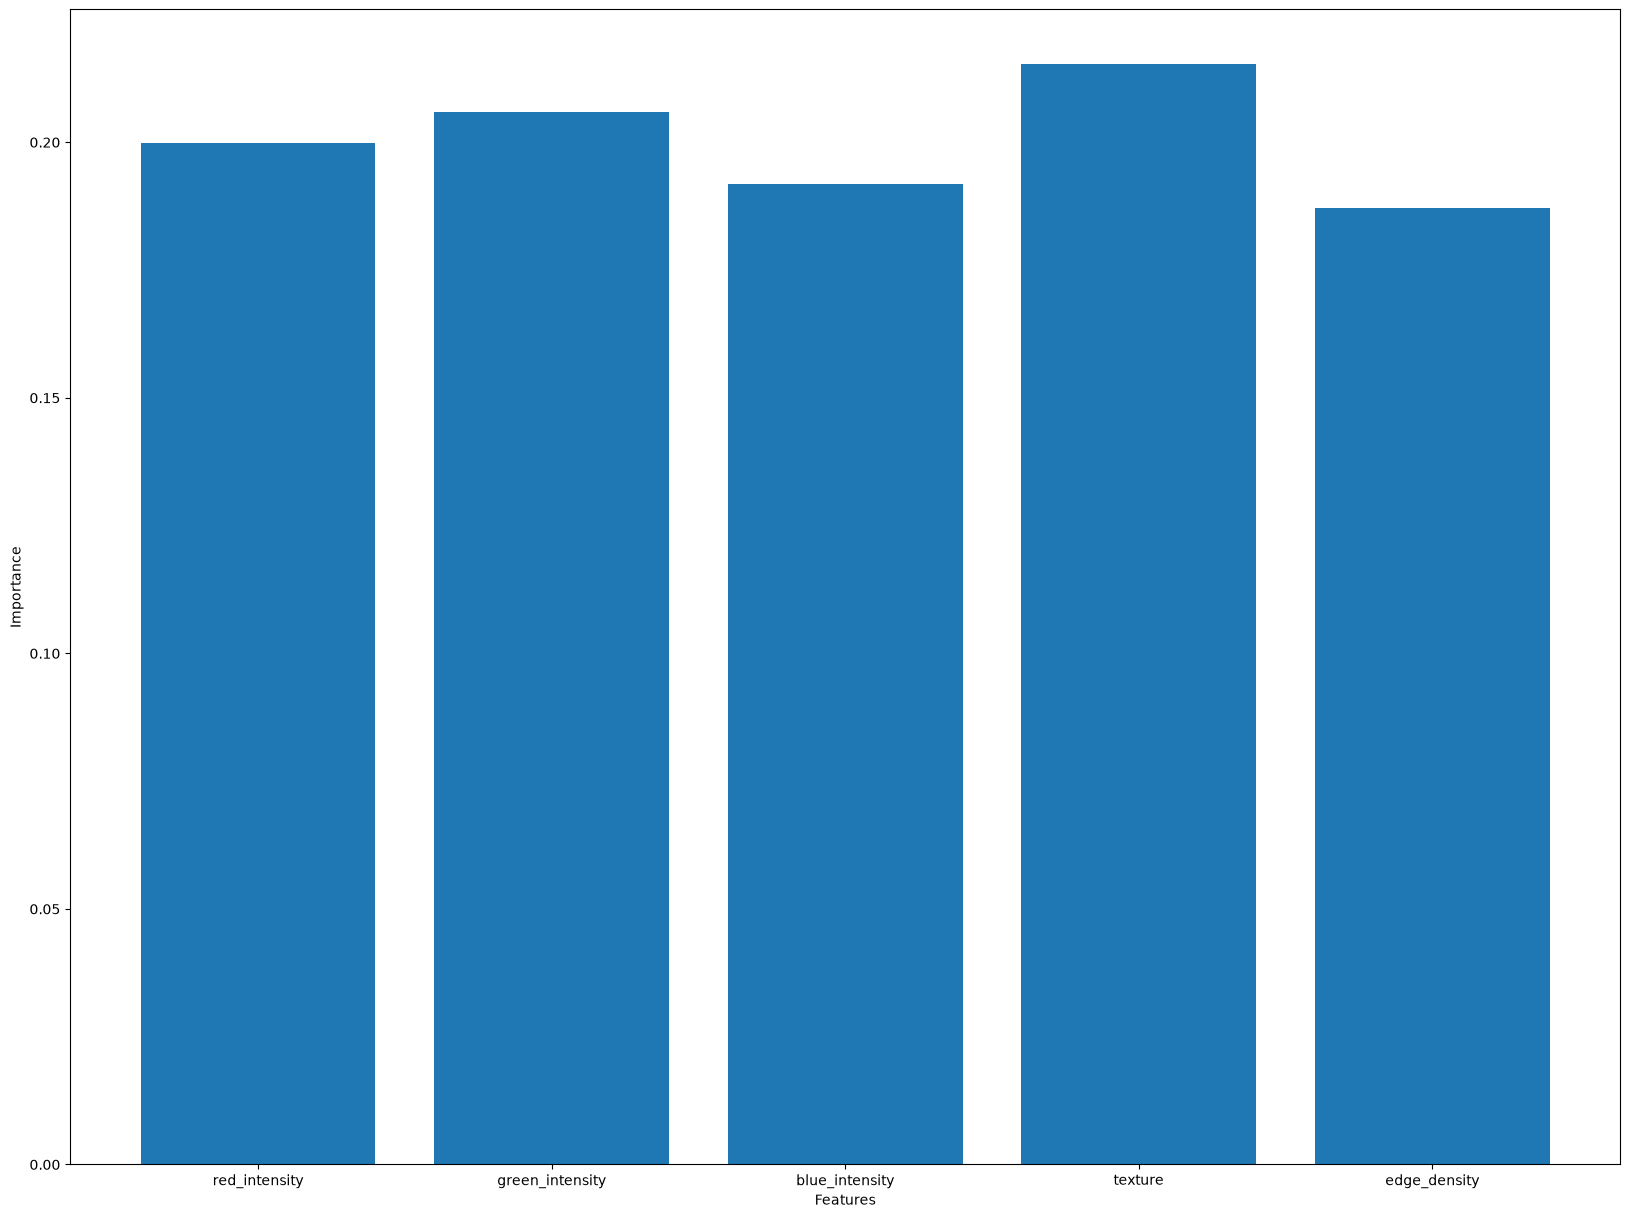

In [13]:
# Graph of feature Importances
plt.figure(figsize=(20,15))
plt.bar(
    X.columns,
    feature_importances_
)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [14]:
# Visulize random forest
# plt.figure(figsize=(300,250))
# plot_tree(
#     model.estimators_[5],
#     feature_names=X.columns,
#     class_names=model.classes_.astype(str),
#     filled=True,
#     rounded=True,
#     fontsize=50
# )
# plt.title('Random Forest Tree')
# plt.show()

In [53]:
# Classification Report
classification=classification_report(y_test,y_pred)
print("Classification Report:",classification)

Classification Report:               precision    recall  f1-score   support

           0       0.69      0.69      0.69       309
           1       0.68      0.66      0.67       319
           2       0.69      0.64      0.66       294
           3       0.74      0.84      0.79       303
           4       0.71      0.70      0.70       292
           5       0.84      0.75      0.80       295
           6       0.73      0.81      0.77       288

    accuracy                           0.73      2100
   macro avg       0.73      0.73      0.73      2100
weighted avg       0.73      0.73      0.72      2100



In [40]:
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:",con_matrix)

Confusion Matrix: [[213  17  16  21  10  11  21]
 [ 17 210  21  23  27  11  10]
 [ 21  34 187  13  22   4  13]
 [ 14  10   8 254   3   5   9]
 [ 16  13  28  11 203   5  16]
 [ 18   8   4  12  12 222  19]
 [ 10  15   8   8   8   5 234]]


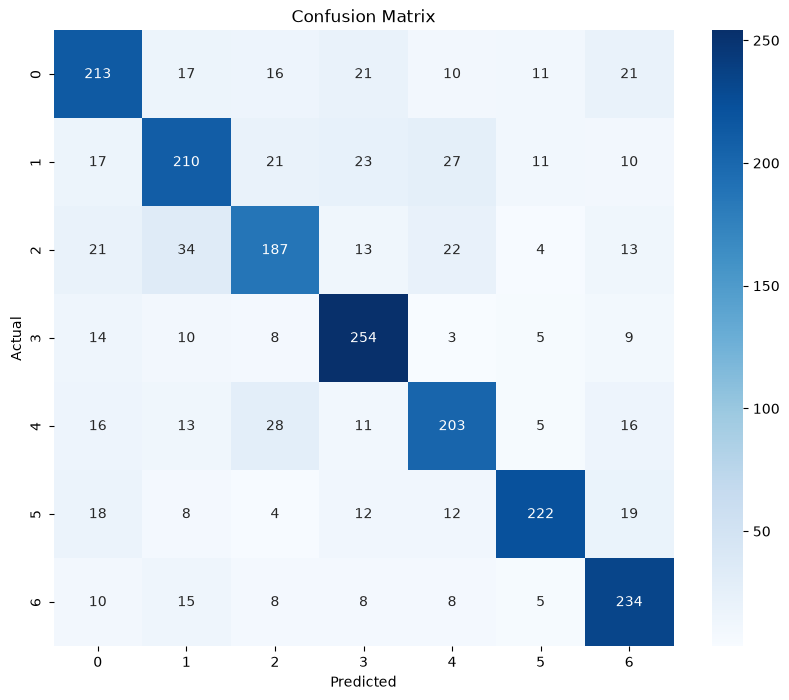

In [84]:
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [69]:
# Roc Auc score
roc_score = roc_auc_score(
    y_test,
    proba,
    multi_class='ovr',
    average='weighted'
)
print("ROC & AUC:",roc_score)

ROC & AUC: 0.9440787924142945


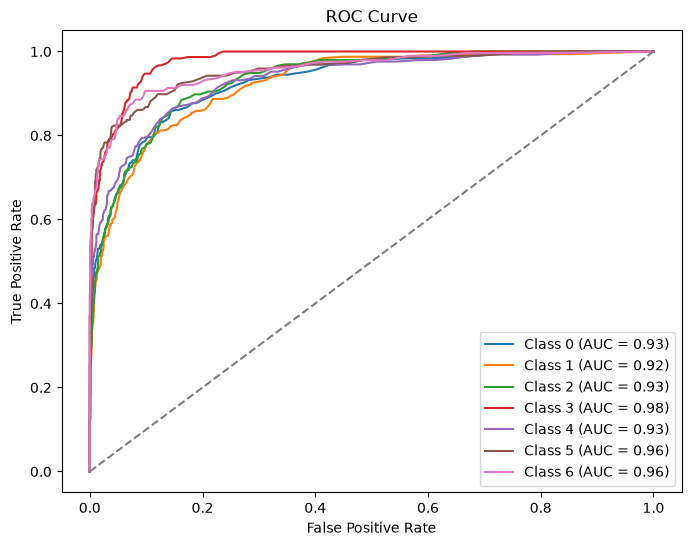

In [75]:
# Roc curve
y_test_bin = label_binarize(y_test, classes=model.classes_)

plt.figure(figsize=(8, 6))

for i in range(len(model.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    roc_score = roc_auc_score(y_test_bin[:, i], proba[:, i])
    
    plt.plot(fpr, tpr, label=f'Class {model.classes_[i]} (AUC = {roc_score:.2f})')

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

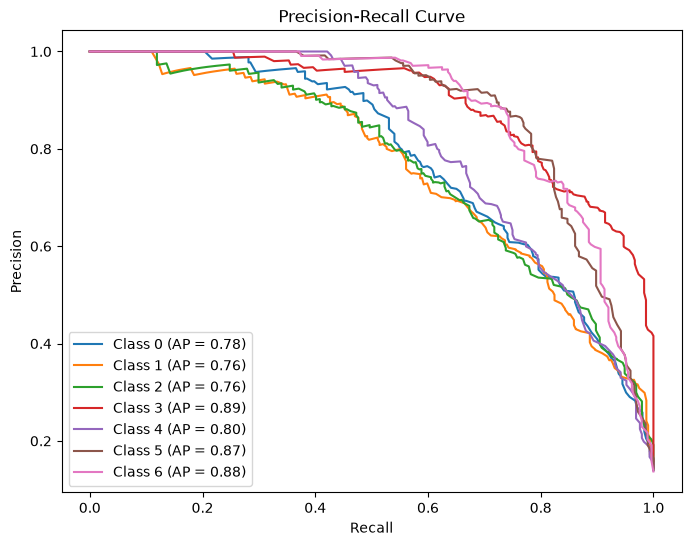

In [80]:
# Precision-Recall Curve
y_test_bin = label_binarize(y_test, classes=model.classes_)

plt.figure(figsize=(8, 6))

for i in range(len(model.classes_)):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        proba[:, i]
    )
    
    pr_score = average_precision_score(
        y_test_bin[:, i],
        proba[:, i]
    )
    
    plt.plot(
        recall,
        precision,
        label=f'Class {model.classes_[i]} (AP = {pr_score:.2f})'
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()